# Confusion Matrix 

In [2]:
import numpy as np 
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix 
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression 


In [4]:
#loading the dataset 
data=pd.read_csv('../dataset/heart.csv')

In [5]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [6]:
x=data.drop(columns='target',axis=1)
y=data.target

In [7]:
print(x)
print(y)

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     63    1   3       145   233    1        0      150      0      2.3   
1     37    1   2       130   250    0        1      187      0      3.5   
2     41    0   1       130   204    0        0      172      0      1.4   
3     56    1   1       120   236    0        1      178      0      0.8   
4     57    0   0       120   354    0        1      163      1      0.6   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
298   57    0   0       140   241    0        1      123      1      0.2   
299   45    1   3       110   264    0        1      132      0      1.2   
300   68    1   0       144   193    1        1      141      0      3.4   
301   57    1   0       130   131    0        1      115      1      1.2   
302   57    0   1       130   236    0        0      174      0      0.0   

     slope  ca  thal  
0        0   0     1  
1        0   0     2  
2        2   0    

In [9]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=3)

In [10]:
model=LogisticRegression(max_iter=1000)

In [11]:
model.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [13]:
train_pre=model.predict(x_train)
train_acc=accuracy_score(y_train,train_pre)

In [14]:
print(train_acc)

0.8512396694214877


In [16]:
test_pre=model.predict(x_test)
test_acc=accuracy_score(y_test,test_pre)

In [17]:
print(test_acc)

0.8852459016393442


# confusion Matrix

In [21]:
cf_matrix = confusion_matrix(y_test,test_pre)
print(cf_matrix)

[[16  5]
 [ 2 38]]


In [31]:
cf_matrix1 = confusion_matrix(y_train,train_pre)
print(cf_matrix1)

[[ 93  24]
 [ 12 113]]


In [24]:
tp,fp,fn,tn=cf_matrix.ravel()
print(tp,fp,fn,tn)

16 5 2 38


In [25]:
tp,fp,fn,tn=cf_matrix1.ravel()
print(tp,fp,fn,tn)

93 24 12 113


In [26]:
import seaborn as sns 

<Axes: >

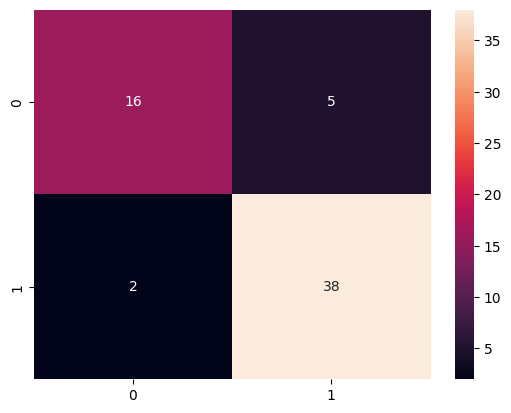

In [27]:
sns.heatmap(cf_matrix,annot=True)


# precision 

In [34]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score 
from sklearn.metrics import f1_score 

In [33]:
#precision on training
precision_train=precision_score(y_train,train_pre)
print("the precision score on training data is ",round(precision_train*100,2),"%")

the precision score on training data is  82.48 %


In [36]:
def precision_recall_f1score(true_value,predicted_value):
    precision_value=precision_score(true_value,predicted_value)
    recall_value=recall_score(true_value,predicted_value)
    f1_score_value=f1_score(true_value,predicted_value)
    print("the precision score  is ",round(precision_value*100,2),"%")
    print("the recall score  is ",round(recall_value*100,2),"%")
    print("the f1 score  is ",round(f1_score_value*100,2),"%")
    

In [37]:
# for training data
precision_recall_f1score(y_train,train_pre)

the precision score  is  82.48 %
the recall score  is  90.4 %
the f1 score  is  86.26 %


In [38]:
#for testing the data 
precision_recall_f1score(y_test,test_pre)

the precision score  is  88.37 %
the recall score  is  95.0 %
the f1 score  is  91.57 %
